# 7. Modelado Baseline Multi-Versión — Screening Preanestésico

**Objetivo**: comparar fácilmente diferentes estrategias de construcción de target.

## Flujo
1. Cargar datasets mergeados por versión
2. Cargar variables seleccionadas por versión
3. Entrenar modelos baseline por versión
4. Comparar métricas (incluye **Accuracy**, ROC-AUC, F1, F2, Recall, Precision)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import warnings
import sys
from pathlib import Path

warnings.filterwarnings("ignore")

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.version_config import ACTIVE_VERSIONS, VERSION_HISTORY
from utils.multi_version import (
    run_pre_post_linkage_analysis,
    run_cross_validation,
    run_modeling_pipeline,
    run_hyperparameter_experiments,
)
import utils.modeling as mod
import utils.visualization as viz

RANDOM_STATE = 42

DATA_DIR = Path("../data")
MERGED_DIR = DATA_DIR / "merged_versions"
FEATURES_VERSIONED_DIR = Path("../features/versioned")
MODELING_RESULTS_DIR = DATA_DIR / "modeling_results"
MODELING_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Versiones activas: {ACTIVE_VERSIONS}")


Versiones activas: ['target_a_sensible', 'target_b_clinicamente_relevante', 'target_c_alta_severidad', 'target_d_eventos_adversos', 'target_e_alta_senal']


## 2. Carga de Artefactos por Versión

In [2]:
# Análisis de señal PRE→POS: cuánto predicen las variables preoperatorias
# cada flag posoperatorio individual (no solo el target agregado)
pre_post_artifacts = run_pre_post_linkage_analysis(
    merged_dir=MERGED_DIR,
    output_dir=MODELING_RESULTS_DIR / "pre_post_signal",
    pos_dir=DATA_DIR,  # directorio con OPERA_POS_*.xlsx
    active_versions=ACTIVE_VERSIONS,
)

print("\n=== RESUMEN: Señal preoperatoria por variable posoperatoria ===")
display(
    pre_post_artifacts["flag_summary"].style
        .background_gradient(subset=["Max_MI"], cmap="RdYlGn")
        .format({"Prevalencia": "{:.1%}", "Max_MI": "{:.4f}", "Max_Pearson": "{:.4f}"})
)



[target_a_sensible] Features PRE: 233 | Variables POS: 57
  flag_acv_hemorragico                          prevalencia=0.0%  max_MI=0.0082  n_informativas=0
  flag_aferesis                                 prevalencia=2.6%  max_MI=0.0063  n_informativas=0
  flag_aspiracion_pulmonar                      prevalencia=0.0%  max_MI=0.0064  n_informativas=0
  flag_balance_extremo                          prevalencia=0.4%  max_MI=0.0064  n_informativas=0
  flag_cancelacion                              prevalencia=0.0%  max_MI=0.0064  n_informativas=0
  flag_complicacion                             prevalencia=0.0%  max_MI=0.0064  n_informativas=0
  flag_complicaciones_medicas                   prevalencia=0.6%  max_MI=0.0072  n_informativas=0
  flag_complicaciones_pulmonares                prevalencia=0.5%  max_MI=0.0070  n_informativas=0
  flag_control_manual                           prevalencia=1.7%  max_MI=0.0061  n_informativas=0
  flag_desenlace                                prevalencia

,Version,Post_Variable,Prevalencia,Max_MI,Max_Pearson,N_Features_Informativas,Top3_Features_PRE
0,target_a_sensible,flag_estancia,19.4%,0.1297,0.3030,14,score_proc_moderate_severity | score_proc_high_severity | score_proc_medium_severity
1,target_a_sensible,flag_hospitalizacion_no_anticipada,19.4%,0.1297,0.3030,14,score_proc_moderate_severity | score_proc_high_severity | score_proc_medium_severity
2,target_a_sensible,flag_tecnica,46.6%,0.0530,0.1469,10,score_proc_medium_severity | score_proc_moderate_severity | score_proc_high_severity
3,target_a_sensible,target,70.8%,0.0488,0.2043,11,score_proc_moderate_severity | score_proc_high_severity | score_proc_critical
4,target_a_sensible,flag_tecnica_combinada,40.8%,0.0485,0.1453,10,score_proc_medium_severity | score_proc_moderate_severity | score_proc_critical
5,target_a_sensible,flag_tiempos,9.5%,0.0429,0.1568,10,score_proc_moderate_severity | score_proc_high_severity | score_proc_critical
6,target_a_sensible,flag_duracion_cirujano_larga,8.4%,0.0382,0.1358,10,score_proc_moderate_severity | score_proc_high_severity | score_proc_critical
7,target_a_sensible,flag_interconsultas,4.5%,0.0348,0.2350,12,score_proc_low_severity | score_proc_moderate_severity | score_proc_high_severity
8,target_a_sensible,flag_glucometria_anormal,4.0%,0.0301,0.4054,5,Antecedente endocrinológicos_diabetes | Antecedente endocrinológicos_negativo | Antecedentes cardiovasculares_negativo
9,target_a_sensible,flag_presion_sistolica_anormal,4.7%,0.0234,0.2230,6,Edad | Tensión Arterial Sistólica (mm/Hg) | Tensión Arterial Media (mm/Hg)


In [ ]:
# ── Validación Cruzada (K-Fold) ─────────────────────────────────────────────
# Evalúa viabilidad del modelo ANTES del pipeline completo.
# Más rápido que el pipeline completo; detecta si hay señal predictiva real.
# Modelos: RF, XGBoost, HistGB, Logistic Regression — 5 folds estratificados.
cv_results = run_cross_validation(
    merged_dir=MERGED_DIR,
    features_versioned_dir=FEATURES_VERSIONED_DIR,
    output_dir=MODELING_RESULTS_DIR / "cv",
    active_versions=ACTIVE_VERSIONS,
    n_folds=5,
    random_state=RANDOM_STATE,
)

# Resumen: media ± std por versión y modelo
cv_summary = (
    cv_results
    .groupby(["Version", "Model"])[["ROC_AUC", "F2", "Recall", "Precision", "Balanced_Accuracy"]]
    .agg(["mean", "std"])
    .round(4)
)
print("\n=== CROSS-VALIDATION — Resumen por versión y modelo ===")
display(cv_summary)

# Ranking compacto: mejor modelo por versión según ROC-AUC medio
cv_best = (
    cv_results.groupby(["Version", "Model"])[["ROC_AUC", "F2", "Recall"]]
    .mean()
    .reset_index()
    .sort_values(["Version", "ROC_AUC"], ascending=[True, False])
    .groupby("Version")
    .head(1)
    .reset_index(drop=True)
)
print("\n=== Mejor modelo por versión (ROC-AUC medio) ===")
display(cv_best.round(4))


Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0
[cv] target_a_sensible: 5-fold CV completo para 4 modelos
Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0
[cv] target_b_clinicamente_relevante: 5-fold CV completo para 4 modelos
Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0
[cv] target_c_alta_severidad: 5-fold CV completo para 4 modelos
Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0


In [ ]:
modeling_artifacts = run_modeling_pipeline(
    merged_dir=MERGED_DIR,
    features_versioned_dir=FEATURES_VERSIONED_DIR,
    output_dir=MODELING_RESULTS_DIR,
    random_state=RANDOM_STATE,
    active_versions=ACTIVE_VERSIONS,
    balance_mode="train_only",  # none | train_only | train_test
    threshold_metric="balanced_accuracy",  # f1 | f2 | balanced_accuracy
    threshold_prevalence_tolerance=0.5,
    val_size=0.1,
    test_size=0.2,
)

print(f"Versiones en común: {len(modeling_artifacts['experiment_registry'])}")
print(f"Estrategias evaluadas: {len(modeling_artifacts['results'])}")
print("Split aplicado: train/validation/test (threshold optimizado en validation, métricas en test)")
print("Balanceo aplicado: train_only (solo entrenamiento balanceado)")
print("Threshold aplicado: balanced_accuracy con restricción de prevalencia en validation")

Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0


[02:11:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:11:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:11:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:11:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:11:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0


[02:13:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:13:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:13:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:13:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:13:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0


...

Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0


[02:17:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:17:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:17:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:17:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:17:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0


[02:20:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:20:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:20:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:20:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[02:20:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Versiones en común: 5
Estrategias evaluadas: 50
Split aplicado: train/validation/test (threshold optimizado en validation, métricas en test)
Balanceo aplicado: train_only (solo entrenamiento balanceado)
Threshold aplicado: balanced_accuracy con restricción de prevalencia en validation


In [ ]:
print(f"Versiones activas: {ACTIVE_VERSIONS}")
display(pd.DataFrame(VERSION_HISTORY))

experiment_registry = modeling_artifacts["experiment_registry"]
ignored_versions = modeling_artifacts.get("ignored_versions", [])

if ignored_versions:
    print("Versiones ignoradas (no activas):", ignored_versions)

experiment_registry

Versiones activas: ['target_a_sensible', 'target_b_clinicamente_relevante', 'target_c_alta_severidad', 'target_d_eventos_adversos', 'target_e_alta_senal']


,version,threshold,flags_to_use,apply_cancel_non_medico_rule,export_name,description,executed_on,notes
0,v1,1,"[flag_cancelacion, flag_reservas, flag_fisiolo...",True,OPERA_POS_v1.xlsx,Baseline completo con TODAS las flags (>=1 flag),2026-02-28,Baseline histórico completo
1,v2,2,"[flag_cancelacion, flag_reservas, flag_fisiolo...",True,OPERA_POS_v2.xlsx,Con agregación (>=2 flags),2026-02-28,Baseline histórico
2,v3_sin_liquidos,1,"[flag_cancelacion, flag_via_aerea, flag_desenl...",True,OPERA_POS_v3_sin_liquidos.xlsx,Sin flag_liquidos (>=1 flag),2026-02-28,Sensibilidad clínica


Versiones ignoradas (no activas): ['v1', 'v2', 'v3_sin_liquidos', 'v4_preop_focus', 'v5_preop_focus_agregado', 'v6_preop_strict']


,version,dataset_path,features_path
0,target_a_sensible,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_a_sensible_select...
1,target_b_clinicamente_relevante,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_b_clinicamente_re...
2,target_c_alta_severidad,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_c_alta_severidad_...
3,target_d_eventos_adversos,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_d_eventos_adverso...
4,target_e_alta_senal,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_e_alta_senal_sele...


In [ ]:
experiment_registry

,version,dataset_path,features_path
0,target_a_sensible,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_a_sensible_select...
1,target_b_clinicamente_relevante,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_b_clinicamente_re...
2,target_c_alta_severidad,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_c_alta_severidad_...
3,target_d_eventos_adversos,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_d_eventos_adverso...
4,target_e_alta_senal,../data/merged_versions/OPERA_COMPLETO_target_...,../features/versioned/target_e_alta_senal_sele...


## 3. Preparación de Datos por Versión

In [ ]:
df_results = modeling_artifacts["results"]
summary_by_version = modeling_artifacts["summary_by_version"]
pivot_auc = modeling_artifacts["pivot_auc"]
pivot_f2 = modeling_artifacts["pivot_f2"]
pivot_acc = modeling_artifacts["pivot_accuracy"]
predictions_by_version = modeling_artifacts["predictions_by_version"]
y_test_by_version = modeling_artifacts["y_test_by_version"]
best_version = modeling_artifacts["best_version"]
best_model = modeling_artifacts["best_model"]

print(f"Mejor versión: {best_version}")
print(f"Mejor modelo: {best_model}")

Mejor versión: target_c_alta_severidad
Mejor modelo: Stacking Ensemble


## 4. Entrenamiento Baseline por Versión

In [ ]:
print(f"\nTotal estrategias evaluadas: {len(df_results)}")
df_results.head(20)


Total estrategias evaluadas: 50


,Version,Model,N_Train,N_Val,N_Test,N_Features,Balance_Mode,Real_Prevalence,Train_Prevalence_Used,Train_Pos_Rate_Original,...,PR-AUC,Balanced_Accuracy,Specificity,Brier,Predicted_Positive_Rate,FN_Rate,Threshold,Threshold_Objective_Metric,Threshold_Objective_Score,F2_Validation_OptThreshold
0,target_c_alta_severidad,Stacking Ensemble,6726,2339,4678,233,train_only,0.205456,0.5,0.205437,...,0.451601,0.662035,0.588378,0.208772,0.478196,0.264308,0.47,balanced_accuracy,0.669773,0.589980
1,target_c_alta_severidad,Voting Ensemble,6726,2339,4678,233,train_only,0.205456,0.5,0.205437,...,0.440656,0.656425,0.548023,0.211234,0.516246,0.235172,0.46,balanced_accuracy,0.668032,0.601023
2,target_c_alta_severidad,XGBoost,6726,2339,4678,233,train_only,0.205456,0.5,0.205437,...,0.433400,0.650418,0.530804,0.223447,0.530996,0.229969,0.38,balanced_accuracy,0.656228,0.592043
3,target_c_alta_severidad,Random Forest,6726,2339,4678,233,train_only,0.205456,0.5,0.205437,...,0.444671,0.648011,0.487490,0.217648,0.573322,0.191467,0.47,balanced_accuracy,0.651147,0.602190
4,target_c_alta_severidad,Extra Trees,6726,2339,4678,233,train_only,0.205456,0.5,0.205437,...,0.443593,0.655055,0.591068,0.213312,0.472638,0.280957,0.49,balanced_accuracy,0.653922,0.573019
5,target_c_alta_severidad,Gradient Boosting,6726,2339,4678,233,train_only,0.205456,0.5,0.205437,...,0.436560,0.649099,0.647834,0.210226,0.413425,0.349636,0.50,balanced_accuracy,0.645542,0.527797
6,target_c_alta_severidad,HistGradientBoosting,6726,2339,4678,233,train_only,0.205456,0.5,0.205437,...,0.423695,0.642657,0.596449,0.226597,0.462163,0.311134,0.44,balanced_accuracy,0.652102,0.565131
7,target_d_eventos_adversos,Stacking Ensemble,11884,2339,4678,233,train_only,0.362979,0.5,0.362981,...,0.626996,0.642911,0.756376,0.213981,0.347371,0.470554,0.54,balanced_accuracy,0.631674,0.510766
8,target_d_eventos_adversos,Random Forest,11884,2339,4678,233,train_only,0.362979,0.5,0.362981,...,0.622421,0.636508,0.762416,0.219799,0.336682,0.489399,0.52,balanced_accuracy,0.635194,0.510327
9,target_e_alta_senal,Stacking Ensemble,12612,2339,4678,233,train_only,0.614786,0.5,0.614783,...,0.783544,0.627120,0.501110,0.216545,0.655195,0.246871,0.46,balanced_accuracy,0.620183,0.742086


## 5. Visualización por Versión (todas las estrategias)

MATRICES DE CONFUSIÓN POR VERSIÓN (TODOS LOS MODELOS)

Versión: target_a_sensible


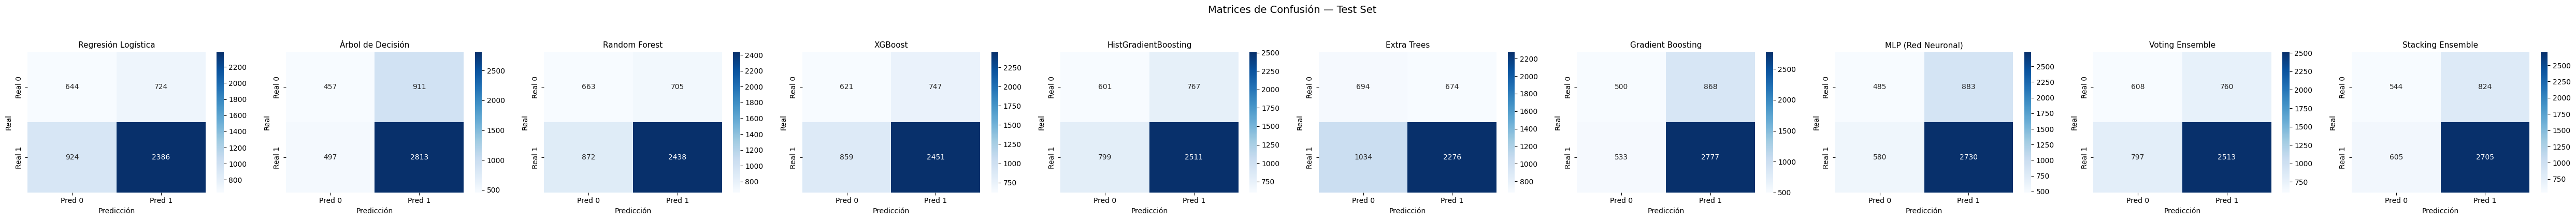


Versión: target_b_clinicamente_relevante


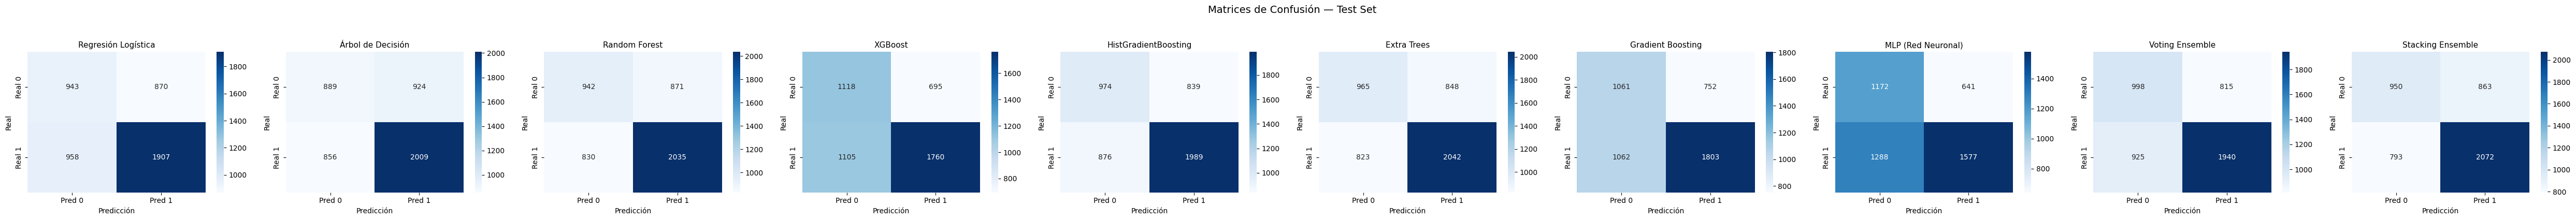


Versión: target_c_alta_severidad


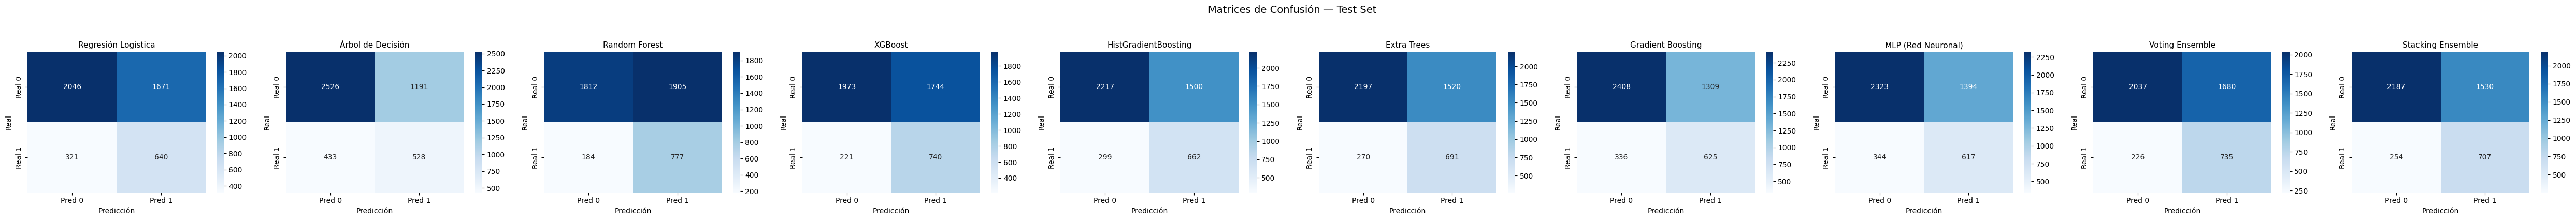


Versión: target_d_eventos_adversos


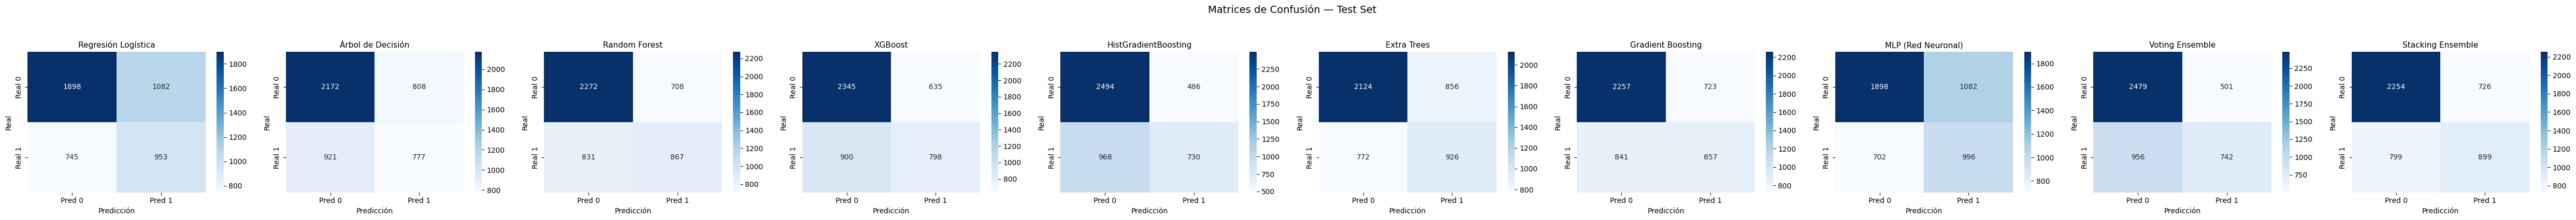


Versión: target_e_alta_senal


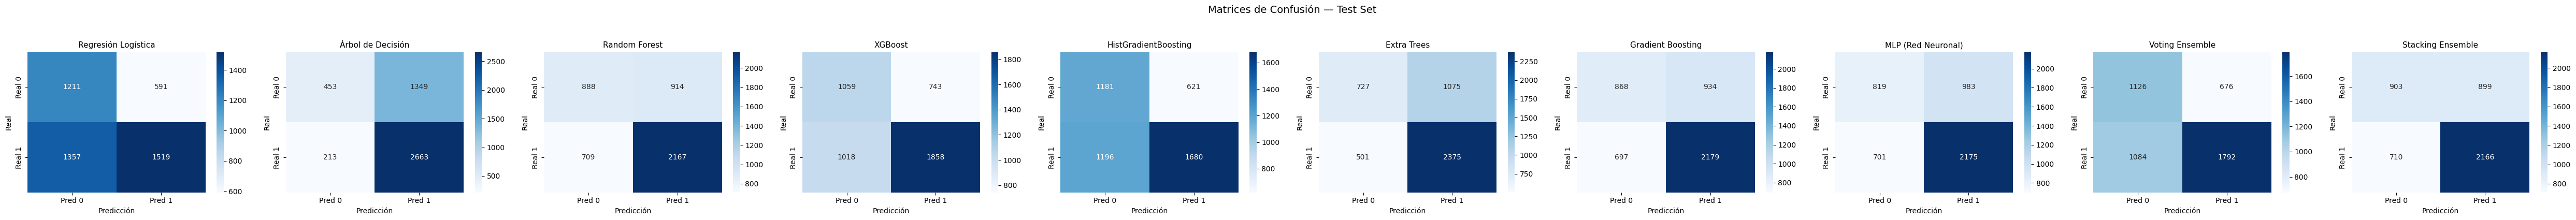

In [ ]:
print("=" * 90)
print("MATRICES DE CONFUSIÓN POR VERSIÓN (TODOS LOS MODELOS)")
print("=" * 90)

for version in sorted(predictions_by_version.keys()):
    print(f"\nVersión: {version}")
    viz.plot_confusion_matrices(
        predictions_by_version[version],
        y_test_by_version[version],
        save_path=f"../matrices_confusion_{version}.png",
    )

CURVAS ROC/PR POR VERSIÓN (TODOS LOS MODELOS)

Versión: target_a_sensible


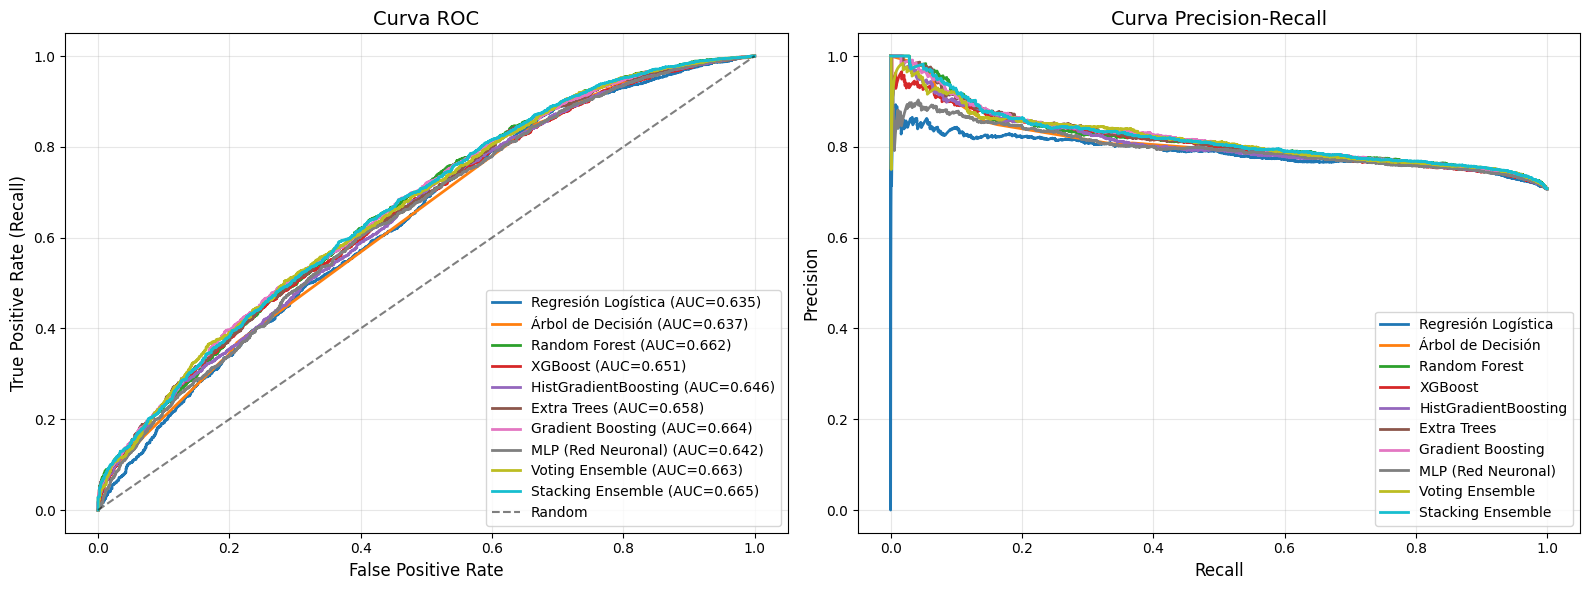


Versión: target_b_clinicamente_relevante


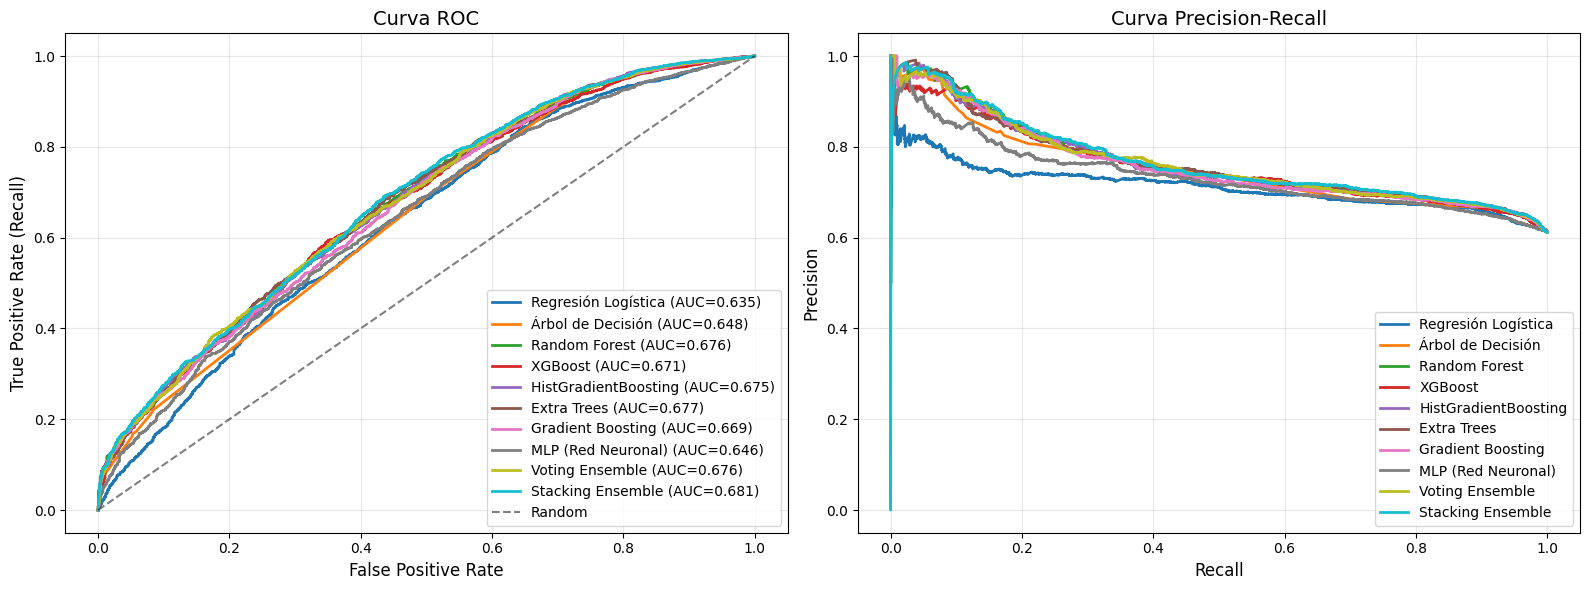


Versión: target_c_alta_severidad


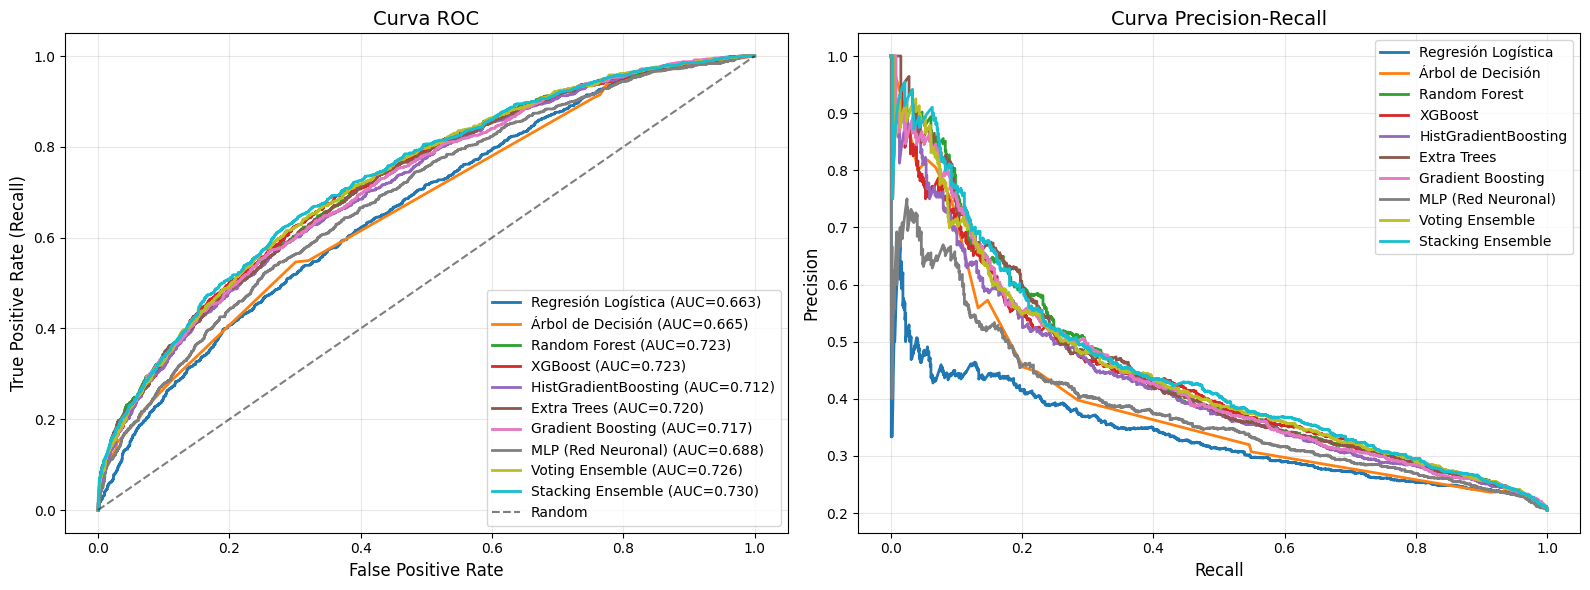


Versión: target_d_eventos_adversos


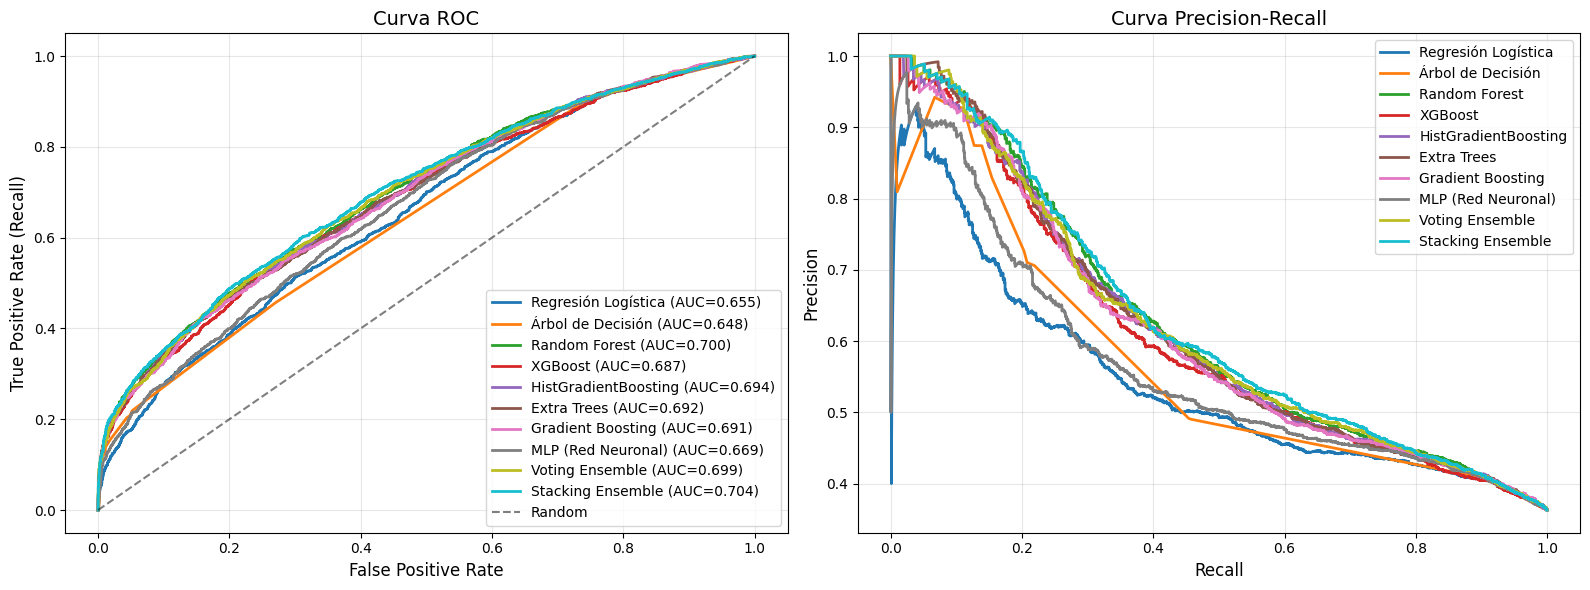


Versión: target_e_alta_senal


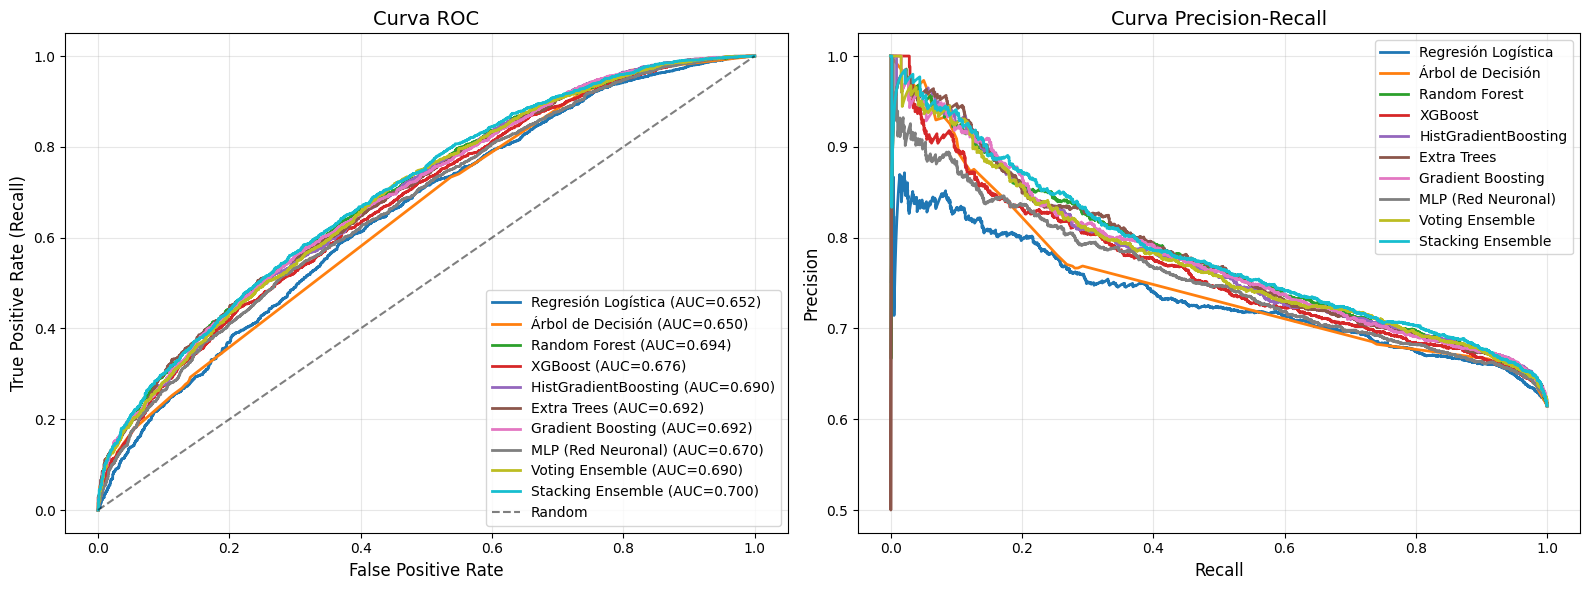

In [ ]:
print("=" * 90)
print("CURVAS ROC/PR POR VERSIÓN (TODOS LOS MODELOS)")
print("=" * 90)

for version in sorted(predictions_by_version.keys()):
    print(f"\nVersión: {version}")
    viz.plot_roc_pr_curves(
        predictions_by_version[version],
        y_test_by_version[version],
        save_path=f"../curvas_roc_pr_{version}.png",
    )

## 6. Comparación Multi-Versión (Baseline + Balanceo de Clases)

In [ ]:
summary_by_version = (
    df_results.sort_values(["Version", "ROC-AUC", "F2", "Accuracy"], ascending=[True, False, False, False])
    .groupby("Version", as_index=False)
    .first()
)

summary_by_version[[
    "Version",
    "Model",
    "Balance_Mode",
    "N_Train", "N_Val", "N_Test",
    "Train_Pos_Rate_Original",
    "Val_Pos_Rate_Original",
    "Test_Pos_Rate_Original",
    "Train_Pos_Rate_Used",
    "Val_Pos_Rate_Used",
    "Test_Pos_Rate_Used",
    "F2_Validation_OptThreshold",
    "Accuracy", "Recall", "Precision", "F1", "F2", "ROC-AUC", "Threshold", "N_Features",
]]

,Version,Model,Balance_Mode,N_Train,N_Val,N_Test,Train_Pos_Rate_Original,Val_Pos_Rate_Original,Test_Pos_Rate_Original,Train_Pos_Rate_Used,...,Test_Pos_Rate_Used,F2_Validation_OptThreshold,Accuracy,Recall,Precision,F1,F2,ROC-AUC,Threshold,N_Features
0,target_a_sensible,Stacking Ensemble,train_only,9578,2339,4678,0.707453,0.707567,0.707567,0.5,...,0.707567,0.803518,0.694528,0.817221,0.766506,0.791051,0.806548,0.664893,0.44,233
1,target_b_clinicamente_relevante,Stacking Ensemble,train_only,12688,2339,4678,0.612462,0.612655,0.612441,0.5,...,0.612441,0.739768,0.646003,0.723211,0.705963,0.714483,0.719694,0.681109,0.48,233
2,target_c_alta_severidad,Stacking Ensemble,train_only,6726,2339,4678,0.205437,0.205643,0.205430,0.5,...,0.205430,0.589980,0.618640,0.735692,0.316048,0.442151,0.581319,0.730335,0.47,233
3,target_d_eventos_adversos,Stacking Ensemble,train_only,11884,2339,4678,0.362981,0.362976,0.362976,0.5,...,0.362976,0.510766,0.674006,0.529446,0.553231,0.541077,0.534038,0.704350,0.54,233


In [ ]:
pivot_auc = df_results.pivot(index="Version", columns="Model", values="ROC-AUC")
pivot_f2 = df_results.pivot(index="Version", columns="Model", values="F2")
pivot_acc = df_results.pivot(index="Version", columns="Model", values="Accuracy")

print("ROC-AUC por versión/modelo")
display(pivot_auc)

print("F2 por versión/modelo")
display(pivot_f2)

print("Accuracy por versión/modelo")
display(pivot_acc)

ROC-AUC por versión/modelo


Model,Extra Trees,Gradient Boosting,HistGradientBoosting,MLP (Red Neuronal),Random Forest,Regresión Logística,Stacking Ensemble,Voting Ensemble,XGBoost,Árbol de Decisión
Version,,,,,,,,,,
target_a_sensible,0.658005,0.664004,0.646373,0.642229,0.661908,0.634518,0.664893,0.662702,0.650800,0.637177
target_b_clinicamente_relevante,0.677438,0.668811,0.675069,0.645827,0.675854,0.635334,0.681109,0.676263,0.670556,0.647753
target_c_alta_severidad,0.719694,0.717254,0.712008,0.688046,0.722694,0.662735,0.730335,0.725997,0.722767,0.664561
target_d_eventos_adversos,0.692413,0.691320,0.693758,0.668548,0.700141,0.655177,0.704350,0.698726,0.687118,0.648237


F2 por versión/modelo


Model,Extra Trees,Gradient Boosting,HistGradientBoosting,MLP (Red Neuronal),Random Forest,Regresión Logística,Stacking Ensemble,Voting Ensemble,XGBoost,Árbol de Decisión
Version,,,,,,,,,,
target_a_sensible,0.702903,0.822328,0.760080,0.809945,0.744064,0.729664,0.806548,0.760916,0.745529,0.829109
target_b_clinicamente_relevante,0.711498,0.643239,0.696039,0.576473,0.708270,0.669734,0.719694,0.682378,0.632411,0.697909
target_c_alta_severidad,0.570603,0.540845,0.551116,0.526900,0.595311,0.519903,0.581319,0.587154,0.584703,0.474564
target_d_eventos_adversos,0.540005,0.511825,0.455794,0.561443,0.518107,0.539821,0.534038,0.461730,0.485106,0.463770


Accuracy por versión/modelo


Model,Extra Trees,Gradient Boosting,HistGradientBoosting,MLP (Red Neuronal),Random Forest,Regresión Logística,Stacking Ensemble,Voting Ensemble,XGBoost,Árbol de Decisión
Version,,,,,,,,,,
target_a_sensible,0.634887,0.700513,0.665242,0.687260,0.662890,0.647713,0.694528,0.667165,0.656691,0.699017
target_b_clinicamente_relevante,0.642796,0.612227,0.633390,0.587644,0.636383,0.609235,0.646003,0.628046,0.615220,0.619496
target_c_alta_severidad,0.617358,0.648354,0.615434,0.628474,0.553442,0.574177,0.618640,0.592561,0.579949,0.652843
target_d_eventos_adversos,0.651988,0.665669,0.689183,0.618640,0.671013,0.609448,0.674006,0.688542,0.671868,0.630398


OPTIMIZACIÓN DE UMBRAL EN VALIDATION (F2, SOLO ANÁLISIS)


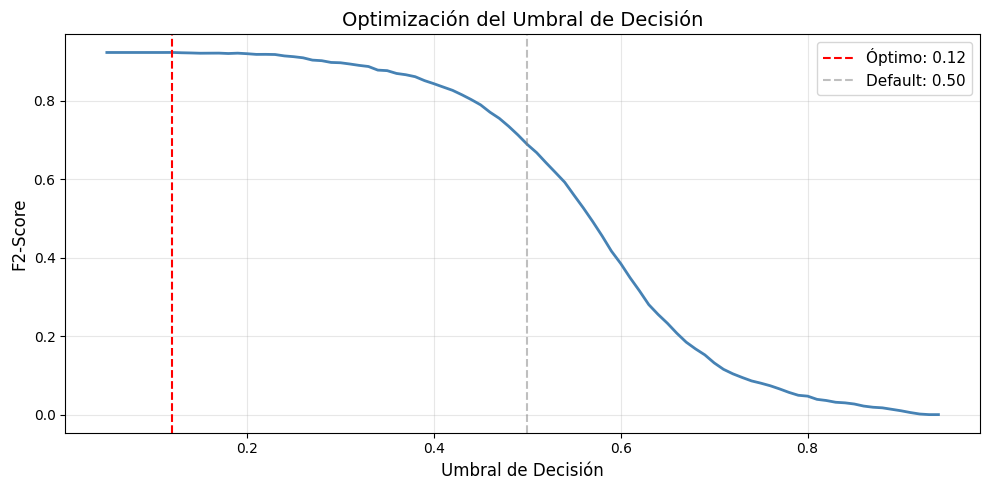

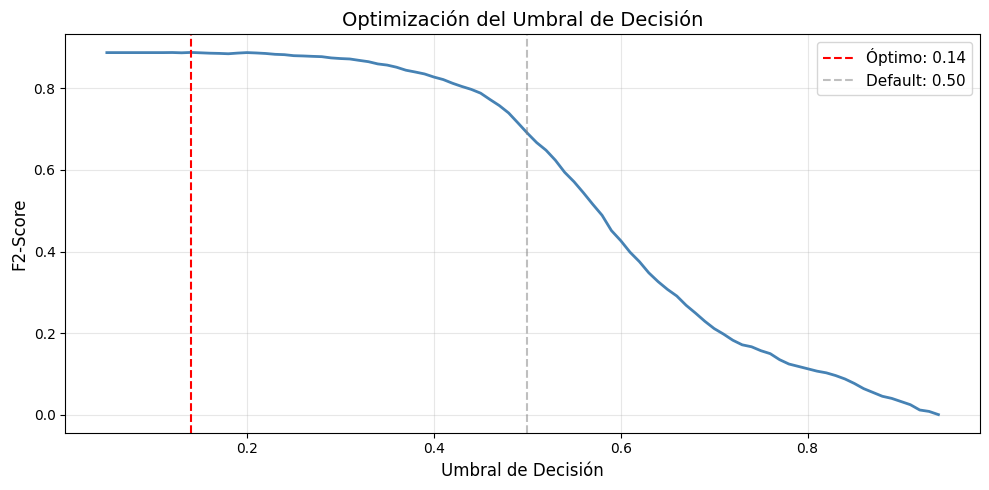

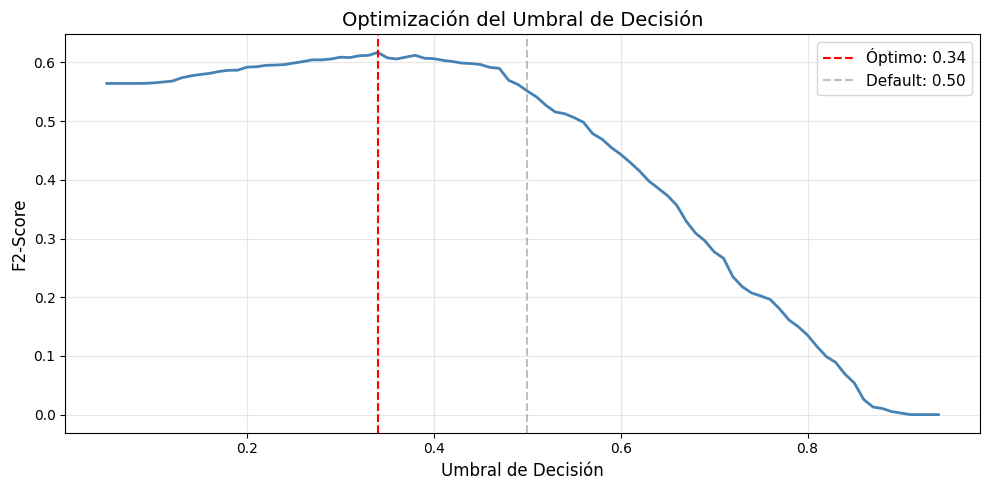

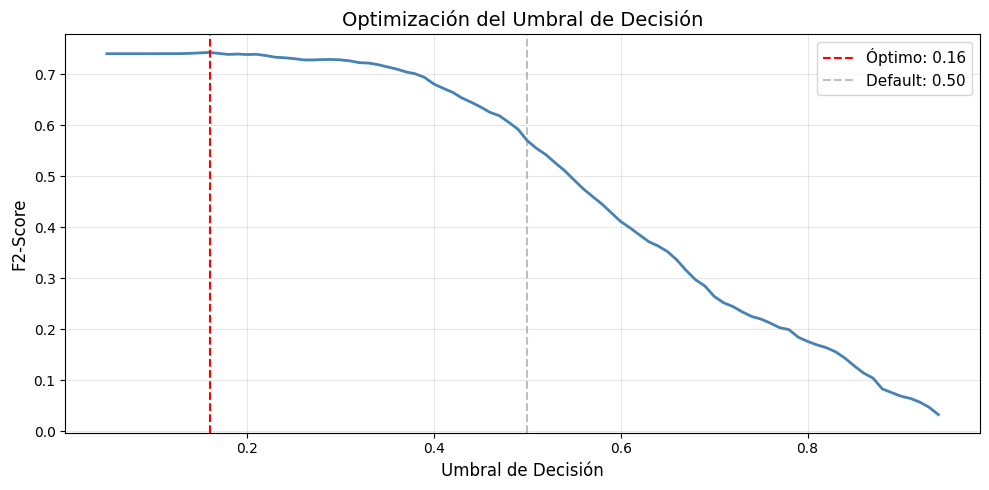

,Version,Model,Threshold_Optimo_F2_Validation,F2_Optimo_Validation
0,target_a_sensible,Stacking Ensemble,0.12,0.9238
1,target_b_clinicamente_relevante,Stacking Ensemble,0.14,0.8882
2,target_c_alta_severidad,Stacking Ensemble,0.34,0.6170
3,target_d_eventos_adversos,Stacking Ensemble,0.16,0.7427


In [ ]:
print("=" * 90)
print("OPTIMIZACIÓN DE UMBRAL EN VALIDATION (F2, SOLO ANÁLISIS)")
print("=" * 90)

y_val_by_version = modeling_artifacts["y_val_by_version"]
threshold_summary_rows = []

for version in sorted(predictions_by_version.keys()):
    version_rows = df_results[df_results["Version"] == version].sort_values(
        ["ROC-AUC", "F2", "Accuracy"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    if version_rows.empty:
        continue

    version_model = version_rows.iloc[0]["Model"]
    y_proba_val = predictions_by_version[version][version_model]["y_val_proba"]

    opt_thresh, opt_f2, thresholds, f2_scores = mod.find_optimal_threshold(
        y_val_by_version[version],
        y_proba_val,
        metric="f2",
    )

    viz.plot_threshold_optimization(
        thresholds,
        f2_scores,
        opt_thresh,
        save_path=f"../umbral_optimo_validation_{version}_{version_model.replace(' ', '_')}.png",
    )

    threshold_summary_rows.append(
        {
            "Version": version,
            "Model": version_model,
            "Threshold_Optimo_F2_Validation": round(float(opt_thresh), 4),
            "F2_Optimo_Validation": round(float(opt_f2), 4),
        }
    )

df_threshold_summary = pd.DataFrame(threshold_summary_rows).sort_values("Version").reset_index(drop=True)
df_threshold_summary

## 7. Explicabilidad por Versión (global y casos)

In [ ]:
explainability_registry = modeling_artifacts["explainability_registry"]
global_expl = modeling_artifacts["explainability_global_by_version"]
case_expl = modeling_artifacts["explainability_cases_by_version"]

print("Registro de explicabilidad por versión:")
display(explainability_registry)

for version in sorted(global_expl.keys()):
    print(f"\n{'='*90}")
    print(f"EXPLICABILIDAD GLOBAL — Versión: {version}")
    print(f"{'='*90}")
    display(global_expl[version].head(20))

    print(f"\nCasos de auditoría clínica — Versión: {version}")
    display(case_expl[version].head(20))

print("\nArchivos exportados:")
for key, value in modeling_artifacts["output_paths"].items():
    print(f"- {key}: {value}")

Registro de explicabilidad por versión:


,Version,Best_Model_For_Explainability,Global_Explainability_Path,Case_Review_Path
0,target_a_sensible,Stacking Ensemble,../data/modeling_results/explainability_global...,../data/modeling_results/explainability_cases_...
1,target_b_clinicamente_relevante,Stacking Ensemble,../data/modeling_results/explainability_global...,../data/modeling_results/explainability_cases_...
2,target_c_alta_severidad,Stacking Ensemble,../data/modeling_results/explainability_global...,../data/modeling_results/explainability_cases_...
3,target_d_eventos_adversos,Stacking Ensemble,../data/modeling_results/explainability_global...,../data/modeling_results/explainability_cases_...



EXPLICABILIDAD GLOBAL — Versión: target_a_sensible


,Feature,Importance,Source
0,Tipo de anestesia propuesta_sedacion,0.051959,permutation_importance
1,Tipo de anestesia propuesta_raquidea,0.018897,permutation_importance
2,Tipo de anestesia propuesta_peridural,0.007159,permutation_importance
3,Examen_Hemoglobina(g/dl),0.006239,permutation_importance
4,Tipo de anestesia propuesta_bloqueo n,0.005036,permutation_importance
5,score_proc_moderate_severity,0.004182,permutation_importance
6,Tipo de anestesia propuesta_general,0.003237,permutation_importance
7,Edad,0.002924,permutation_importance
8,score_proc_low_severity,0.002716,permutation_importance
9,Tensión Arterial Sistólica (mm/Hg),0.002690,permutation_importance



Casos de auditoría clínica — Versión: target_a_sensible


...


EXPLICABILIDAD GLOBAL — Versión: target_d_eventos_adversos


,Feature,Importance,Source
0,Tipo de anestesia propuesta_sedacion,0.037410,permutation_importance
1,Tipo de anestesia propuesta_raquidea,0.025775,permutation_importance
2,Tipo de anestesia propuesta_peridural,0.012341,permutation_importance
3,score_proc_low_severity,0.004357,permutation_importance
4,Dx Preoperatorio Code_S,0.003765,permutation_importance
5,score_dx_high_severity,0.003712,permutation_importance
6,Tipo de anestesia propuesta_local,0.003648,permutation_importance
7,score_proc_critical,0.003617,permutation_importance
8,Dx Preoperatorio Code_Z,0.002935,permutation_importance
9,Examen_Hemoglobina(g/dl),0.002886,permutation_importance



Casos de auditoría clínica — Versión: target_d_eventos_adversos


,case_index,case_type,y_true,y_pred,y_proba,reason
0,11521,FN,1,0,0.539771,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
1,14722,FN,1,0,0.539503,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
2,9404,FN,1,0,0.538942,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
3,12909,FN,1,0,0.538851,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
4,11,FN,1,0,0.538843,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
5,197,FN,1,0,0.538786,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
6,7313,FN,1,0,0.538768,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
7,9250,FN,1,0,0.538723,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
8,17665,FN,1,0,0.538362,Tipo de anestesia propuesta_sedacion=0.0 | Tip...
9,7158,FN,1,0,0.537880,Tipo de anestesia propuesta_sedacion=0.0 | Tip...



Archivos exportados:
- results: ../data/modeling_results/baseline_results_by_version.csv
- summary: ../data/modeling_results/best_model_by_version.csv
- pivot_auc: ../data/modeling_results/pivot_auc.csv
- pivot_f2: ../data/modeling_results/pivot_f2.csv
- pivot_accuracy: ../data/modeling_results/pivot_accuracy.csv
- explainability_registry: ../data/modeling_results/explainability_registry.csv


In [ ]:
top10_global = df_results.head(10).copy()
top10_global[["Version", "Model", "Accuracy", "F2", "ROC-AUC", "Recall", "Precision", "Threshold"]]

,Version,Model,Accuracy,F2,ROC-AUC,Recall,Precision,Threshold
0,target_c_alta_severidad,Stacking Ensemble,0.618640,0.581319,0.730335,0.735692,0.316048,0.47
1,target_c_alta_severidad,Voting Ensemble,0.592561,0.587154,0.725997,0.764828,0.304348,0.46
2,target_c_alta_severidad,XGBoost,0.579949,0.584703,0.722767,0.770031,0.297907,0.38
3,target_c_alta_severidad,Random Forest,0.553442,0.595311,0.722694,0.808533,0.289709,0.47
4,target_c_alta_severidad,Extra Trees,0.617358,0.570603,0.719694,0.719043,0.312528,0.49
5,target_c_alta_severidad,Gradient Boosting,0.648354,0.540845,0.717254,0.650364,0.323164,0.50
6,target_c_alta_severidad,HistGradientBoosting,0.615434,0.551116,0.712008,0.688866,0.306198,0.44
7,target_d_eventos_adversos,Stacking Ensemble,0.674006,0.534038,0.704350,0.529446,0.553231,0.54
8,target_d_eventos_adversos,Random Forest,0.671013,0.518107,0.700141,0.510601,0.550476,0.52
9,target_d_eventos_adversos,Voting Ensemble,0.688542,0.461730,0.698726,0.436985,0.596943,0.57


## 8. Experimentos de entrenamiento (tuning + combinaciones)

Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0
Optimizing hyperparameters for: XGBoost (Target: f2)
Optimizing hyperparameters for: Random Forest (Target: f2)
Optimizing hyperparameters for: HistGradientBoosting (Target: f2)
Optimizing hyperparameters for: Regresión Logística (Target: f2)
Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0
Optimizing hyperparameters for: XGBoost (Target: f2)
Optimizing hyperparameters for: Random Forest (Target: f2)
Optimizing hyperparameters for: HistGradientBoosting (Target: f2)
Optimizing hyperparameters for: Regresión Logística (Target: f2)
Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0
Optimizing hyperparameters for: XGBoost (Target: f2)
Optimizing hyperparameters for: Random Forest (Target: f2)
Optimizing hyperparameters for: HistGradientBoosting (Target: f2)
Optimi

,Version,Model,Feature_Subset,N_Features,Validation_ROC-AUC,Validation_F2,Test_ROC-AUC,Test_F2,Test_Accuracy,Test_Recall,Test_Precision,Test_Threshold,Tuning_Best_CV_Score,Tuning_N_Trials
0,target_a_sensible,XGBoost,top_100pct,233,0.662121,0.776242,0.660461,0.783248,0.677854,0.788218,0.763982,0.49,0.689993,15
1,target_b_clinicamente_relevante,HistGradientBoosting,top_100pct,233,0.676151,0.724367,0.672794,0.710166,0.634887,0.713438,0.697373,0.50,0.674990,15
2,target_c_alta_severidad,HistGradientBoosting,top_100pct,233,0.714699,0.525327,0.716867,0.523649,0.665883,0.612903,0.330899,0.53,0.639216,15
3,target_d_eventos_adversos,Random Forest,top_100pct,233,0.694097,0.522681,0.697565,0.517611,0.664386,0.512367,0.539702,0.52,0.616698,15


Top 20 experimentos de tuning:


,Version,Model,Feature_Subset,N_Features,Test_ROC-AUC,Test_F2,Test_Accuracy,Test_Recall,Test_Precision,Test_Threshold,Validation_ROC-AUC,Validation_F2,Tuning_Best_CV_Score,Best_Params
0,target_c_alta_severidad,HistGradientBoosting,top_100pct,233,0.716867,0.523649,0.665883,0.612903,0.330899,0.53,0.714699,0.525327,0.639216,"{""max_iter"": 700, ""max_depth"": 14, ""learning_r..."
1,target_c_alta_severidad,XGBoost,top_100pct,233,0.706701,0.507917,0.658829,0.594173,0.321328,0.51,0.716433,0.526974,0.665359,"{""max_depth"": 3, ""learning_rate"": 0.0178578632..."
2,target_c_alta_severidad,Random Forest,top_100pct,233,0.702994,0.560687,0.592988,0.720083,0.297379,0.50,0.715372,0.574834,0.691240,"{""n_estimators"": 500, ""max_depth"": 6, ""min_sam..."
3,target_d_eventos_adversos,Random Forest,top_100pct,233,0.697565,0.517611,0.664386,0.512367,0.539702,0.52,0.694097,0.522681,0.616698,"{""n_estimators"": 700, ""max_depth"": 26, ""min_sa..."
4,target_d_eventos_adversos,XGBoost,top_100pct,233,0.693677,0.466667,0.680633,0.445230,0.577982,0.57,0.689426,0.475692,0.615186,"{""max_depth"": 10, ""learning_rate"": 0.024609144..."
5,target_d_eventos_adversos,HistGradientBoosting,top_100pct,233,0.683936,0.555556,0.641941,0.569494,0.506018,0.50,0.688480,0.558566,0.606711,"{""max_iter"": 700, ""max_depth"": 10, ""learning_r..."
6,target_b_clinicamente_relevante,HistGradientBoosting,top_100pct,233,0.672794,0.710166,0.634887,0.713438,0.697373,0.50,0.676151,0.724367,0.674990,"{""max_iter"": 100, ""max_depth"": 11, ""learning_r..."
7,target_b_clinicamente_relevante,Random Forest,top_100pct,233,0.672404,0.610206,0.604959,0.588482,0.715924,0.51,0.675115,0.638542,0.659662,"{""n_estimators"": 1000, ""max_depth"": 11, ""min_s..."
8,target_c_alta_severidad,Regresión Logística,top_100pct,233,0.665402,0.489810,0.612655,0.595213,0.286717,0.52,0.682539,0.510257,0.637851,"{""C"": 3.7881978692730853}"
9,target_b_clinicamente_relevante,XGBoost,top_100pct,233,0.664746,0.749387,0.641086,0.767539,0.684620,0.45,0.676285,0.761668,0.638852,"{""max_depth"": 3, ""learning_rate"": 0.0318315854..."


Comparación directa Baseline vs Tuning (mejor por versión):


,Version,Baseline_Model,N_Train,N_Val,N_Test,N_Features,Balance_Mode,Real_Prevalence,Train_Prevalence_Used,Train_Pos_Rate_Original,...,Threshold_Objective_Score,F2_Validation_OptThreshold,Tuned_Model,Tuned_Feature_Subset,Tuned_ROC-AUC,Tuned_F2,Tuned_Accuracy,Delta_ROC-AUC,Delta_F2,Delta_Accuracy
0,target_a_sensible,Stacking Ensemble,9578,2339,4678,233,train_only,0.707487,0.5,0.707453,...,0.617728,0.803518,XGBoost,top_100pct,0.660461,0.783248,0.677854,-0.004432,-0.023300,-0.016674
3,target_d_eventos_adversos,Stacking Ensemble,11884,2339,4678,233,train_only,0.362979,0.5,0.362981,...,0.631674,0.510766,Random Forest,top_100pct,0.697565,0.517611,0.664386,-0.006785,-0.016428,-0.009619
1,target_b_clinicamente_relevante,Stacking Ensemble,12688,2339,4678,233,train_only,0.612477,0.5,0.612462,...,0.636036,0.739768,HistGradientBoosting,top_100pct,0.672794,0.710166,0.634887,-0.008314,-0.009528,-0.011116
2,target_c_alta_severidad,Stacking Ensemble,6726,2339,4678,233,train_only,0.205456,0.5,0.205437,...,0.669773,0.589980,HistGradientBoosting,top_100pct,0.716867,0.523649,0.665883,-0.013468,-0.057670,0.047242


Comparación visual: top n modelos por métrica


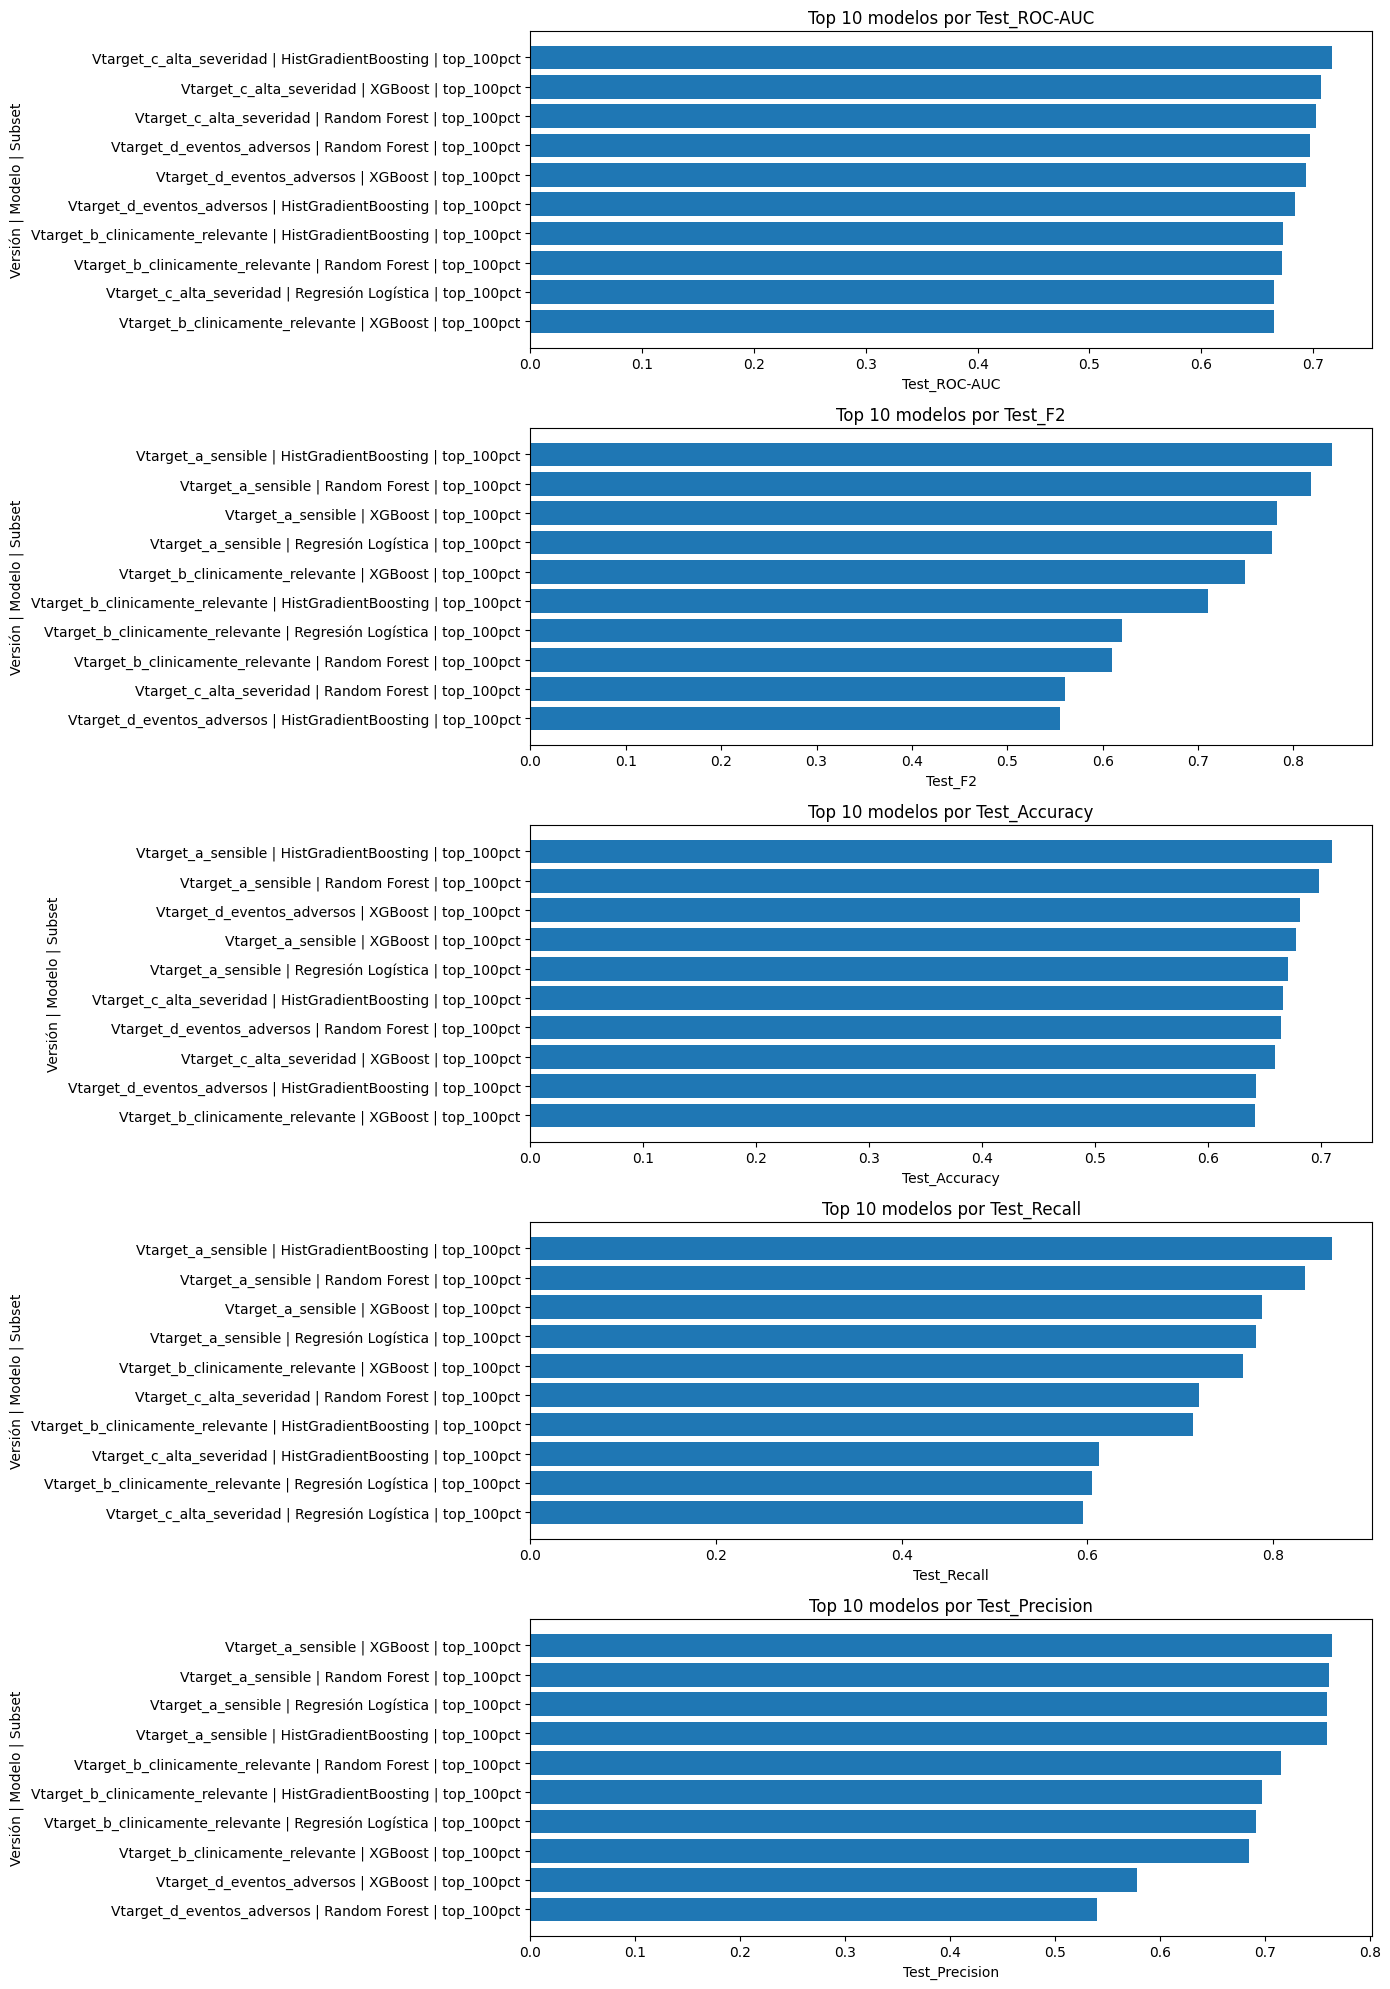

Archivos de tuning exportados:
- experiments: ../data/modeling_results/hyperparameter_experiments.csv
- best_by_version: ../data/modeling_results/hyperparameter_best_by_version.csv


In [ ]:
hyper_artifacts = run_hyperparameter_experiments(
    merged_dir=MERGED_DIR,
    features_versioned_dir=FEATURES_VERSIONED_DIR,
    output_dir=MODELING_RESULTS_DIR,
    random_state=RANDOM_STATE,
    active_versions=ACTIVE_VERSIONS,
    balance_mode="train_only",
    val_size=0.2,
    test_size=0.2,
    threshold_metric="balanced_accuracy",
    threshold_prevalence_tolerance=0.5,
    tune_models=["XGBoost", "Random Forest", "HistGradientBoosting", "Regresión Logística"],
    optimize_metric="f2",
    n_trials=15,
    feature_subset_fractions=(1.0,),
)

df_hyper = hyper_artifacts["experiments"]
df_hyper_best = hyper_artifacts["best_by_version"]

print("Mejores resultados de tuning por versión:")
display(
    df_hyper_best[[
        "Version", "Model", "Feature_Subset", "N_Features",
        "Validation_ROC-AUC", "Validation_F2",
        "Test_ROC-AUC", "Test_F2", "Test_Accuracy", "Test_Recall", "Test_Precision", "Test_Threshold",
        "Tuning_Best_CV_Score", "Tuning_N_Trials",
    ]]
)

print("Top 20 experimentos de tuning:")
display(
    df_hyper[[
        "Version", "Model", "Feature_Subset", "N_Features",
        "Test_ROC-AUC", "Test_F2", "Test_Accuracy", "Test_Recall", "Test_Precision", "Test_Threshold",
        "Validation_ROC-AUC", "Validation_F2", "Tuning_Best_CV_Score", "Best_Params",
    ]].head(20)
)

print("Comparación directa Baseline vs Tuning (mejor por versión):")
baseline_best = (
    df_results.sort_values(["Version", "ROC-AUC", "F2"], ascending=[True, False, False])
    .groupby("Version", as_index=False)
    .first()
    .rename(columns={
        "Model": "Baseline_Model",
        "ROC-AUC": "Baseline_ROC-AUC",
        "F2": "Baseline_F2",
        "Accuracy": "Baseline_Accuracy",
    })
)

comparison = baseline_best.merge(
    df_hyper_best[["Version", "Model", "Feature_Subset", "Test_ROC-AUC", "Test_F2", "Test_Accuracy"]],
    on="Version",
    how="left",
).rename(columns={
    "Model": "Tuned_Model",
    "Feature_Subset": "Tuned_Feature_Subset",
    "Test_ROC-AUC": "Tuned_ROC-AUC",
    "Test_F2": "Tuned_F2",
    "Test_Accuracy": "Tuned_Accuracy",
})

comparison["Delta_ROC-AUC"] = comparison["Tuned_ROC-AUC"] - comparison["Baseline_ROC-AUC"]
comparison["Delta_F2"] = comparison["Tuned_F2"] - comparison["Baseline_F2"]
comparison["Delta_Accuracy"] = comparison["Tuned_Accuracy"] - comparison["Baseline_Accuracy"]

display(comparison.sort_values("Delta_ROC-AUC", ascending=False))

print("Comparación visual: top n modelos por métrica")
import matplotlib.pyplot as plt

n_top_models = 10
metric_cols = [
    "Test_ROC-AUC",
    "Test_F2",
    "Test_Accuracy",
    "Test_Recall",
    "Test_Precision",
]

df_plot = df_hyper.copy()
df_plot["Experiment_Label"] = (
    "V" + df_plot["Version"].astype(str)
    + " | " + df_plot["Model"].astype(str)
    + " | " + df_plot["Feature_Subset"].astype(str)
)

n_metrics = len(metric_cols)
fig, axes = plt.subplots(nrows=n_metrics, ncols=1, figsize=(14, 4 * n_metrics))

if n_metrics == 1:
    axes = [axes]

for ax, metric in zip(axes, metric_cols):
    top_metric = (
        df_plot.sort_values(metric, ascending=False)
        .head(n_top_models)
        .sort_values(metric, ascending=True)
    )
    ax.barh(top_metric["Experiment_Label"], top_metric[metric])
    ax.set_title(f"Top {n_top_models} modelos por {metric}")
    ax.set_xlabel(metric)
    ax.set_ylabel("Versión | Modelo | Subset")

plt.tight_layout()
plt.show()

print("Archivos de tuning exportados:")
for key, value in hyper_artifacts["output_paths"].items():
    print(f"- {key}: {value}")